# Rossmann Store Sales Forecasting Workshop

In this notebook we go through a complete forecasting workflow using the Rossmann store sales data.

The aim is to predict daily store sales using historical data, store information, promotions, holidays, and engineered features.

We will not use the official Kaggle `test.csv` for evaluation. Instead, we will create our own transparent test period by hiding the final month of sales from `train.csv`.

## 0. Files needed

Put the following files in a folder called `data` next to this notebook:

```text
data/
    train.csv
    store.csv
```

Optional, but not needed for this classroom workflow:

```text
data/
    test.csv
    sample_submission.csv
```

We use:

- `train.csv`: historical store-day data with known `Sales`.
- `store.csv`: one row per store, containing store characteristics.

In [1]:
# If needed, uncomment this line:
# !pip install pandas numpy scikit-learn xgboost matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

## 1. Load the data

The main sales file has one row per store per day.

The store file has one row per store.

We merge them using the `Store` column.

In [2]:
train = pd.read_csv(
    "data/train.csv",
    parse_dates=["Date"],
    dtype={"StateHoliday": str},
    low_memory=False
)

store = pd.read_csv("data/store.csv")

data = train.merge(store, on="Store", how="left")

print("train shape:", train.shape)
print("store shape:", store.shape)
print("merged data shape:", data.shape)

data.head()

train shape: (1017209, 9)
store shape: (1115, 10)
merged data shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2. Inspect the variables

Important columns include:

- `Store`: store identifier.
- `Date`: date of the observation.
- `Sales`: daily sales turnover. This is the target variable.
- `Customers`: number of customers that day. We will not use this as a predictor because future customer numbers would not be known in a real forecast.
- `Open`: whether the store was open.
- `Promo`: whether a promotion was running.
- `StateHoliday`: type of state holiday.
- `SchoolHoliday`: whether the store was affected by school holidays.
- `StoreType`, `Assortment`, `CompetitionDistance`, `Promo2`: store-level information.

In [3]:
print(data.info())
data[["Date", "Store", "Sales", "Customers", "Open", "Promo", "StateHoliday", "SchoolHoliday"]].head()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

,Date,Store,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,2015-07-31,1,5263,555,1,1,0,1
1,2015-07-31,2,6064,625,1,1,0,1
2,2015-07-31,3,8314,821,1,1,0,1
3,2015-07-31,4,13995,1498,1,1,0,1
4,2015-07-31,5,4822,559,1,1,0,1


## 3. Check the date range

Forecasting must respect time order: train on earlier dates and test on later dates.

First date: 2013-01-01 00:00:00
Last date: 2015-07-31 00:00:00


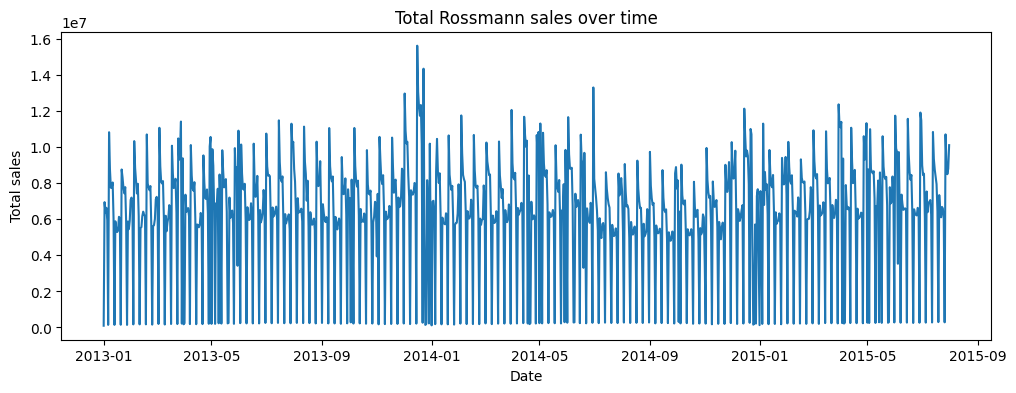

In [4]:
print("First date:", data["Date"].min())
print("Last date:", data["Date"].max())

daily_sales = data.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12, 4))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Total Rossmann sales over time")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.show()

## 4. Create our own hidden test month

The official `test.csv` does not contain the true `Sales` values.

For this workshop, we use July 2015 as our transparent test period:

- Training period: before 1 July 2015.
- Test period: from 1 July 2015 onwards.

We keep a private copy of the true July sales so we can evaluate the forecast.

In [5]:
cutoff_date = pd.Timestamp("2015-07-01")

model_train = data[data["Date"] < cutoff_date].copy()
model_test = data[data["Date"] >= cutoff_date].copy()

y_test_true = model_test["Sales"].copy()
model_test_without_sales = model_test.drop(columns=["Sales"])

print("Training period:", model_train["Date"].min(), "to", model_train["Date"].max())
print("Test period:", model_test["Date"].min(), "to", model_test["Date"].max())
print("Training rows:", len(model_train))
print("Test rows:", len(model_test))

Training period: 2013-01-01 00:00:00 to 2015-06-30 00:00:00
Test period: 2015-07-01 00:00:00 to 2015-07-31 00:00:00
Training rows: 982644
Test rows: 34565


## 5. Evaluation metric: RMSPE

The Rossmann competition used Root Mean Square Percentage Error:

$$
\mathrm{RMSPE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\frac{y_i - \widehat{y}_i}{y_i}
\right)^2
}
$$

Rows with true sales equal to zero are excluded from the calculation because percentage error would be undefined.

In [25]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

## 6. Baseline model

Before using machine learning, we need a simple benchmark.

Baseline:

- If the store is closed, predict 0.
- Otherwise, predict the average historical sales of that store.

In [26]:
store_average_sales = (
    model_train[(model_train["Open"] == 1) & (model_train["Sales"] > 0)]
    .groupby("Store")["Sales"]
    .mean()
)

global_average_sales = (
    model_train[(model_train["Open"] == 1) & (model_train["Sales"] > 0)]
    ["Sales"]
    .mean()
)

baseline_pred = model_test_without_sales["Store"].map(store_average_sales)
baseline_pred = baseline_pred.fillna(global_average_sales)

baseline_pred = np.where(
    model_test_without_sales["Open"].fillna(1).values == 0,
    0,
    baseline_pred
)

baseline_score = rmspe(y_test_true, baseline_pred)
print("Baseline RMSPE:", baseline_score)

Baseline RMSPE: 0.737310782835904


## 7. First feature engineering stage

We create features from the date and store description columns.

These are features that would be known in advance for future dates.

In [27]:
def add_date_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
    df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)
    return df


def clean_missing_values(df):
    df = df.copy()
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(999999)

    for col in [
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear",
        "PromoInterval",
    ]:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    df["Open"] = df["Open"].fillna(1)
    return df


def add_competition_features(df):
    df = df.copy()
    df["CompetitionOpen"] = 12 * (
        df["Year"] - df["CompetitionOpenSinceYear"]
    ) + (
        df["Month"] - df["CompetitionOpenSinceMonth"]
    )

    df.loc[
        (df["CompetitionOpenSinceYear"] == 0)
        | (df["CompetitionOpenSinceMonth"] == 0),
        "CompetitionOpen"
    ] = 0

    df["CompetitionOpen"] = df["CompetitionOpen"].clip(lower=0)
    return df


def add_promo2_features(df):
    df = df.copy()
    df["Promo2Open"] = 12 * (
        df["Year"] - df["Promo2SinceYear"]
    ) + (
        df["WeekOfYear"] - df["Promo2SinceWeek"]
    ) / 4.0

    df.loc[
        (df["Promo2"] == 0)
        | (df["Promo2SinceYear"] == 0)
        | (df["Promo2SinceWeek"] == 0),
        "Promo2Open"
    ] = 0

    df["Promo2Open"] = df["Promo2Open"].clip(lower=0)
    return df

In [28]:
model_train_fe = add_date_features(model_train)
model_test_fe = add_date_features(model_test_without_sales)

model_train_fe = clean_missing_values(model_train_fe)
model_test_fe = clean_missing_values(model_test_fe)

model_train_fe = add_competition_features(model_train_fe)
model_test_fe = add_competition_features(model_test_fe)

model_train_fe = add_promo2_features(model_train_fe)
model_test_fe = add_promo2_features(model_test_fe)

model_train_fe.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoInterval,Year,Month,Day,WeekOfYear,DayOfYear,IsMonthStart,IsMonthEnd,CompetitionOpen,Promo2Open
34565,1,2,2015-06-30,5735,568,1,1,0,0,c,...,0,2015,6,30,27,181,0,1,81.0,0.00
34566,2,2,2015-06-30,9863,877,1,1,0,0,a,...,"Jan,Apr,Jul,Oct",2015,6,30,27,181,0,1,91.0,63.50
34567,3,2,2015-06-30,13261,1072,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,6,30,27,181,0,1,102.0,51.25
34568,4,2,2015-06-30,13106,1488,1,1,0,0,c,...,0,2015,6,30,27,181,0,1,69.0,0.00
34569,5,2,2015-06-30,6635,645,1,1,0,0,a,...,0,2015,6,30,27,181,0,1,2.0,0.00


## 8. Encode categorical variables

XGBoost needs numerical inputs.

We convert categorical variables into dummy variables.

We combine training and test rows before encoding so that both datasets get exactly the same columns.

In [29]:
categorical_cols = ["StoreType", "Assortment", "StateHoliday", "PromoInterval"]

combined = pd.concat(
    [
        model_train_fe.drop(columns=["Sales", "Customers"], errors="ignore"),
        model_test_fe.drop(columns=["Customers"], errors="ignore")
    ],
    axis=0
)

combined_encoded = pd.get_dummies(combined, columns=categorical_cols, dummy_na=True)

X_train_basic = combined_encoded.iloc[:len(model_train_fe)].copy()
X_test_basic = combined_encoded.iloc[len(model_train_fe):].copy()

X_train_basic = X_train_basic.drop(columns=["Date"], errors="ignore")
X_test_basic = X_test_basic.drop(columns=["Date"], errors="ignore")

y_train = model_train_fe["Sales"].copy()

print("Training matrix:", X_train_basic.shape)
print("Test matrix:", X_test_basic.shape)

Training matrix: (982644, 39)
Test matrix: (34565, 39)


## 9. First XGBoost model

We train only on open stores with positive sales.

The model predicts `log(1 + Sales)`, then we convert back to sales.

In [30]:
open_train_mask = (model_train_fe["Open"] == 1) & (model_train_fe["Sales"] > 0)

X_train_open_basic = X_train_basic.loc[open_train_mask].copy()
y_train_open_log = np.log1p(y_train.loc[open_train_mask])

model_basic = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_basic.fit(X_train_open_basic, y_train_open_log)

pred_log_basic = model_basic.predict(X_test_basic)
pred_basic = np.expm1(pred_log_basic)

pred_basic = np.where(model_test_fe["Open"].fillna(1).values == 0, 0, pred_basic)

basic_score = rmspe(y_test_true, pred_basic)

print("Baseline RMSPE:", baseline_score)
print("Basic XGBoost RMSPE:", basic_score)

Baseline RMSPE: 0.737310782835904
Basic XGBoost RMSPE: 0.7523665832385702


## 10. Inspect predictions

Good forecasting practice is not only computing a score.

We should inspect where the model performs badly.

In [31]:
results_basic = model_test.copy()
results_basic["BaselinePrediction"] = baseline_pred
results_basic["XGBoostPrediction"] = pred_basic
results_basic["AbsoluteError"] = abs(results_basic["Sales"] - results_basic["XGBoostPrediction"])
results_basic["PercentageError"] = results_basic["AbsoluteError"] / results_basic["Sales"].replace(0, np.nan)

results_basic[
    ["Store", "Date", "Sales", "BaselinePrediction", "XGBoostPrediction", "AbsoluteError", "PercentageError", "Open", "Promo", "StateHoliday", "SchoolHoliday"]
].head(20)

,Store,Date,Sales,BaselinePrediction,XGBoostPrediction,AbsoluteError,PercentageError,Open,Promo,StateHoliday,SchoolHoliday
0,1,2015-07-31,5263,4768.684350,5819.324219,556.324219,0.105705,1,1,0,1
1,2,2015-07-31,6064,4953.887715,6607.544434,543.544434,0.089635,1,1,0,1
2,3,2015-07-31,8314,6947.773936,9597.471680,1283.471680,0.154375,1,1,0,1
3,4,2015-07-31,13995,9616.343461,11819.055664,2175.944336,0.155480,1,1,0,1
4,5,2015-07-31,4822,4679.026596,6456.705566,1634.705566,0.339010,1,1,0,1
5,6,2015-07-31,5651,5547.305445,6300.577148,649.577148,0.114949,1,1,0,1
6,7,2015-07-31,15344,8764.483531,11771.368164,3572.631836,0.232836,1,1,0,1
7,8,2015-07-31,8492,5505.741083,7463.625977,1028.374023,0.121099,1,1,0,1
8,9,2015-07-31,8565,6539.210106,9172.848633,607.848633,0.070969,1,1,0,1
9,10,2015-07-31,7185,5552.085865,6886.433594,298.566406,0.041554,1,1,0,1


In [32]:
results_basic.sort_values("PercentageError", ascending=False)[
    ["Store", "Date", "Sales", "XGBoostPrediction", "AbsoluteError", "PercentageError", "Open", "Promo", "StateHoliday", "SchoolHoliday"]
].head(20)

,Store,Date,Sales,XGBoostPrediction,AbsoluteError,PercentageError,Open,Promo,StateHoliday,SchoolHoliday
23706,292,2015-07-10,1012,5245.183594,4233.183594,4.182988,1,0,0,0
34358,909,2015-07-01,3547,12489.063477,8942.063477,2.521022,1,1,0,0
7190,501,2015-07-25,1571,4498.601562,2927.601562,1.863527,1,0,0,0
30396,292,2015-07-04,1646,4710.226562,3064.226562,1.861620,1,0,0,0
18715,876,2015-07-15,4739,10857.636719,6118.636719,1.291124,1,1,0,1
7703,1014,2015-07-25,2954,6374.772949,3420.772949,1.158014,1,0,0,0
25936,292,2015-07-08,2406,5117.906738,2711.906738,1.127143,1,0,0,0
7645,956,2015-07-25,904,1871.701172,967.701172,1.070466,1,0,0,0
31118,1014,2015-07-04,3948,8023.612793,4075.612793,1.032323,1,0,0,0
29866,877,2015-07-05,1845,3721.837402,1876.837402,1.017256,1,0,0,0


## 11. Recent-history features

The winning-style strategy makes strong use of recent data.

We now create features based on past sales, such as:

- sales 7 days ago;
- sales 14 days ago;
- rolling mean over the previous 7, 14, 28 and 56 days;
- typical sales for the store on that day of the week;
- typical sales for the store with or without promotion.

Important rule:

For a row at date \(t\), we must not use sales from date \(t\) or later.

In [33]:
def add_recent_history_features(full_data, cutoff_date):
    # Adds leakage-safe recent-history features.
    # For a row at date t, rolling features use only dates before t.
    # Aggregate features are computed from the training period only.

    df = full_data.copy()
    df = df.sort_values(["Store", "Date"])

    df["SalesForHistory"] = df["Sales"].where(
        (df["Open"] == 1) & (df["Sales"] > 0),
        np.nan
    )

    df["SalesLag7"] = df.groupby("Store")["SalesForHistory"].shift(7)
    df["SalesLag14"] = df.groupby("Store")["SalesForHistory"].shift(14)
    df["SalesLag28"] = df.groupby("Store")["SalesForHistory"].shift(28)

    for window in [7, 14, 28, 56]:
        df[f"RollingMean{window}"] = (
            df.groupby("Store")["SalesForHistory"]
            .transform(lambda x: x.shift(1).rolling(window, min_periods=3).mean())
        )

    for window in [7, 28]:
        df[f"RollingMedian{window}"] = (
            df.groupby("Store")["SalesForHistory"]
            .transform(lambda x: x.shift(1).rolling(window, min_periods=3).median())
        )

    train_only = df[df["Date"] < cutoff_date].copy()

    store_mean = (
        train_only.groupby("Store")["SalesForHistory"]
        .mean()
        .rename("StoreMeanSales")
        .reset_index()
    )

    store_dow_mean = (
        train_only.groupby(["Store", "DayOfWeek"])["SalesForHistory"]
        .mean()
        .rename("StoreDayOfWeekMeanSales")
        .reset_index()
    )

    store_promo_mean = (
        train_only.groupby(["Store", "Promo"])["SalesForHistory"]
        .mean()
        .rename("StorePromoMeanSales")
        .reset_index()
    )

    store_month_mean = (
        train_only.groupby(["Store", "Month"])["SalesForHistory"]
        .mean()
        .rename("StoreMonthMeanSales")
        .reset_index()
    )

    df = df.merge(store_mean, on="Store", how="left")
    df = df.merge(store_dow_mean, on=["Store", "DayOfWeek"], how="left")
    df = df.merge(store_promo_mean, on=["Store", "Promo"], how="left")
    df = df.merge(store_month_mean, on=["Store", "Month"], how="left")

    df["RollingMean7_vs_StoreMean"] = df["RollingMean7"] / df["StoreMeanSales"]
    df["RollingMean28_vs_StoreMean"] = df["RollingMean28"] / df["StoreMeanSales"]

    history_cols = [
        "SalesLag7", "SalesLag14", "SalesLag28",
        "RollingMean7", "RollingMean14", "RollingMean28", "RollingMean56",
        "RollingMedian7", "RollingMedian28",
        "StoreMeanSales", "StoreDayOfWeekMeanSales",
        "StorePromoMeanSales", "StoreMonthMeanSales",
        "RollingMean7_vs_StoreMean", "RollingMean28_vs_StoreMean",
    ]

    for col in history_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    global_mean_sales = train_only["SalesForHistory"].mean()

    for col in history_cols:
        df[col] = df[col].fillna(df["StoreMeanSales"])
        df[col] = df[col].fillna(global_mean_sales)

    df = df.drop(columns=["SalesForHistory"])
    return df

## 12. Rebuild the dataset with recent-history features

We apply the full feature-engineering pipeline to the merged data.

The cutoff date is passed to the recent-history function so that aggregate features are computed using only the training period.

In [34]:
data_fe2 = add_date_features(data)
data_fe2 = clean_missing_values(data_fe2)
data_fe2 = add_competition_features(data_fe2)
data_fe2 = add_promo2_features(data_fe2)
data_fe2 = add_recent_history_features(data_fe2, cutoff_date=cutoff_date)

model_train_fe2 = data_fe2[data_fe2["Date"] < cutoff_date].copy()
model_test_fe2 = data_fe2[data_fe2["Date"] >= cutoff_date].copy()

y_test_true = model_test_fe2["Sales"].copy()

print(model_train_fe2.shape)
print(model_test_fe2.shape)

model_train_fe2.head()

(982644, 42)
(34565, 42)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,RollingMean28,RollingMean56,RollingMedian7,RollingMedian28,StoreMeanSales,StoreDayOfWeekMeanSales,StorePromoMeanSales,StoreMonthMeanSales,RollingMean7_vs_StoreMean,RollingMean28_vs_StoreMean
0,1,2,2013-01-01,0,0,0,0,a,1,c,...,4768.68435,4768.68435,4768.68435,4768.68435,4768.68435,4697.023077,4331.690647,4703.166667,4768.684350,4768.684350
1,1,3,2013-01-02,5530,668,1,0,0,1,c,...,4768.68435,4768.68435,4768.68435,4768.68435,4768.68435,4561.582677,4331.690647,4703.166667,4768.684350,4768.684350
2,1,4,2013-01-03,4327,578,1,0,0,1,c,...,4768.68435,4768.68435,4768.68435,4768.68435,4768.68435,4454.630252,4331.690647,4703.166667,4768.684350,4768.684350
3,1,5,2013-01-04,4486,619,1,0,0,1,c,...,4768.68435,4768.68435,4768.68435,4768.68435,4768.68435,4737.274194,4331.690647,4703.166667,4768.684350,4768.684350
4,1,6,2013-01-05,4997,635,1,0,0,1,c,...,4781.00000,4781.00000,4486.00000,4486.00000,4768.68435,4963.546154,4331.690647,4703.166667,1.002583,1.002583


## 13. Train XGBoost with recent-history features

In [35]:
combined2 = pd.concat(
    [
        model_train_fe2.drop(columns=["Sales", "Customers"], errors="ignore"),
        model_test_fe2.drop(columns=["Sales", "Customers"], errors="ignore")
    ],
    axis=0
)

combined2_encoded = pd.get_dummies(combined2, columns=categorical_cols, dummy_na=True)

X_train_history = combined2_encoded.iloc[:len(model_train_fe2)].copy()
X_test_history = combined2_encoded.iloc[len(model_train_fe2):].copy()

X_train_history = X_train_history.drop(columns=["Date"], errors="ignore")
X_test_history = X_test_history.drop(columns=["Date"], errors="ignore")

y_train_history = model_train_fe2["Sales"].copy()

open_train_mask2 = (model_train_fe2["Open"] == 1) & (model_train_fe2["Sales"] > 0)

X_train_history_open = X_train_history.loc[open_train_mask2].copy()
y_train_history_open_log = np.log1p(y_train_history.loc[open_train_mask2])

model_history = XGBRegressor(
    n_estimators=900,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_history.fit(X_train_history_open, y_train_history_open_log)

pred_log_history = model_history.predict(X_test_history)
pred_history = np.expm1(pred_log_history)

pred_history = np.where(model_test_fe2["Open"].fillna(1).values == 0, 0, pred_history)

history_score = rmspe(y_test_true, pred_history)

print("Baseline RMSPE:", baseline_score)
print("Basic XGBoost RMSPE:", basic_score)
print("XGBoost with recent-history features RMSPE:", history_score)

Baseline RMSPE: 0.737310782835904
Basic XGBoost RMSPE: 0.7523665832385702
XGBoost with recent-history features RMSPE: 0.11570720378074231


## 14. Correction factor for log-sales predictions

We trained on `log(1 + Sales)` but evaluate using percentage error.

A small correction to the log-prediction can improve RMSPE.

For demonstration, we choose this correction on the held-out month. In a production workflow, this correction should be tuned on a validation set before the final test set.

In [36]:
def find_best_correction(y_true, pred_log, open_values):
    best_correction = 0
    best_score = float("inf")

    for correction in np.linspace(-0.12, 0.05, 171):
        pred = np.expm1(pred_log + correction)
        pred = np.where(open_values == 0, 0, pred)
        score = rmspe(y_true, pred)

        if score < best_score:
            best_score = score
            best_correction = correction

    return best_correction, best_score


best_corr, corrected_score = find_best_correction(
    y_true=y_test_true,
    pred_log=pred_log_history,
    open_values=model_test_fe2["Open"].fillna(1).values
)

pred_history_corrected = np.expm1(pred_log_history + best_corr)
pred_history_corrected = np.where(
    model_test_fe2["Open"].fillna(1).values == 0,
    0,
    pred_history_corrected
)

print("Best correction factor:", best_corr)
print("Corrected RMSPE:", corrected_score)

Best correction factor: -0.015000000000000013
Corrected RMSPE: 0.11466903793405761


## 15. Compare all results

In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline: store average",
        "Basic XGBoost",
        "XGBoost with recent-history features",
        "XGBoost with recent-history features + correction"
    ],
    "RMSPE": [
        baseline_score,
        basic_score,
        history_score,
        corrected_score
    ]
})

comparison

,Model,RMSPE
0,Baseline: store average,0.737311
1,Basic XGBoost,0.752367
2,XGBoost with recent-history features,0.115707
3,XGBoost with recent-history features + correction,0.114669


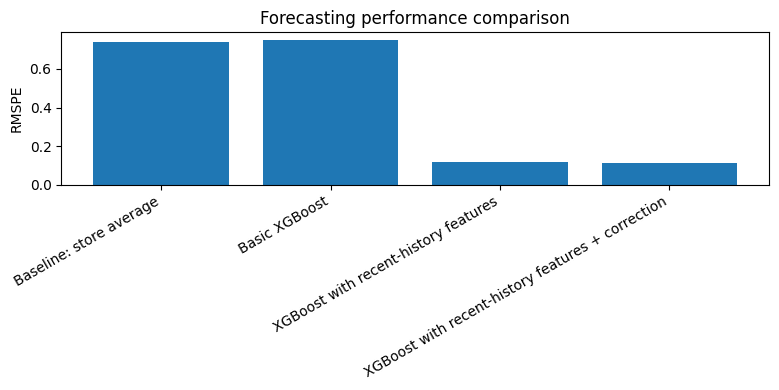

In [38]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["Model"], comparison["RMSPE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSPE")
plt.title("Forecasting performance comparison")
plt.tight_layout()
plt.show()

## 16. Feature importance

XGBoost can report which features were most useful.

This does not prove causality, but it helps us understand what information the model relied on.

In [39]:
importance = pd.DataFrame({
    "Feature": X_train_history.columns,
    "Importance": model_history.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)
importance.head(20)

,Feature,Importance
31,StorePromoMeanSales,0.524106
30,StoreDayOfWeekMeanSales,0.137047
21,SalesLag14,0.094947
3,Promo,0.056022
22,SalesLag28,0.017354
17,IsMonthEnd,0.017091
14,WeekOfYear,0.013419
13,Day,0.010483
1,DayOfWeek,0.010394
24,RollingMean14,0.010042


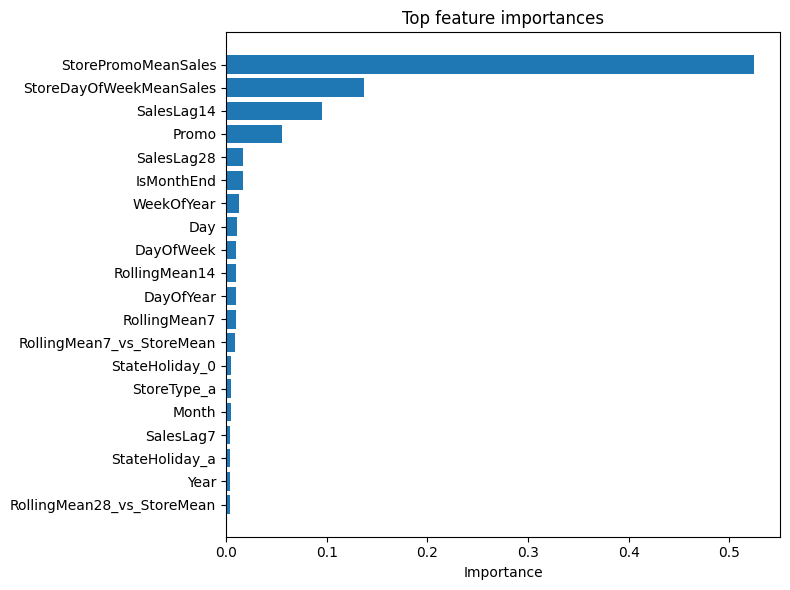

In [40]:
top_n = 20

plt.figure(figsize=(8, 6))
plt.barh(
    importance.head(top_n)["Feature"][::-1],
    importance.head(top_n)["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top feature importances")
plt.tight_layout()
plt.show()

## 17. Inspect final predictions

In [41]:
results_final = model_test_fe2.copy()
results_final["Prediction"] = pred_history_corrected
results_final["AbsoluteError"] = abs(results_final["Sales"] - results_final["Prediction"])
results_final["PercentageError"] = results_final["AbsoluteError"] / results_final["Sales"].replace(0, np.nan)

results_final[
    ["Store", "Date", "Sales", "Prediction", "AbsoluteError", "PercentageError", "Open", "Promo", "StateHoliday", "SchoolHoliday"]
].head(20)

,Store,Date,Sales,Prediction,AbsoluteError,PercentageError,Open,Promo,StateHoliday,SchoolHoliday
911,1,2015-07-01,5223,5023.857078,199.142922,0.038128,1,1,0,0
912,1,2015-07-02,5558,4978.889377,579.110623,0.104194,1,1,0,0
913,1,2015-07-03,4665,4960.165355,295.165355,0.063272,1,1,0,0
914,1,2015-07-04,4797,4526.392214,270.607786,0.056412,1,0,0,0
915,1,2015-07-05,0,0.000000,0.000000,NaN,0,0,0,0
916,1,2015-07-06,4359,3893.315842,465.684158,0.106833,1,0,0,0
917,1,2015-07-07,3650,3798.593710,148.593710,0.040711,1,0,0,0
918,1,2015-07-08,3797,3559.983105,237.016895,0.062422,1,0,0,0
919,1,2015-07-09,3897,3542.326975,354.673025,0.091012,1,0,0,0
920,1,2015-07-10,3808,3833.466619,25.466619,0.006688,1,0,0,0


In [42]:
results_final.sort_values("PercentageError", ascending=False)[
    ["Store", "Date", "Sales", "Prediction", "AbsoluteError", "PercentageError", "Open", "Promo", "StateHoliday", "SchoolHoliday"]
].head(20)

,Store,Date,Sales,Prediction,AbsoluteError,PercentageError,Open,Promo,StateHoliday,SchoolHoliday
828279,909,2015-07-01,3547,14028.079985,10481.079985,2.954914,1,1,0,0
265106,292,2015-07-10,1012,3792.988555,2780.988555,2.748012,1,0,0,0
265100,292,2015-07-04,1646,5010.356797,3364.356797,2.043959,1,0,0,0
798863,876,2015-07-15,4739,11265.438165,6526.438165,1.377176,1,1,0,1
457031,501,2015-07-25,1571,3367.209105,1796.209105,1.143354,1,0,0,0
487174,534,2015-07-02,4488,8598.440313,4110.440313,0.915874,1,1,0,0
265103,292,2015-07-07,3077,5592.681674,2515.681674,0.817576,1,0,0,0
798861,876,2015-07-13,8088,14664.757668,6576.757668,0.813150,1,1,0,1
265099,292,2015-07-03,5036,9043.363303,4007.363303,0.795743,1,1,0,0
863174,947,2015-07-20,3471,6229.094130,2758.094130,0.794611,1,0,0,0


## 18. Plot predictions for one store

Choose a store number and compare actual and predicted sales during the test month.

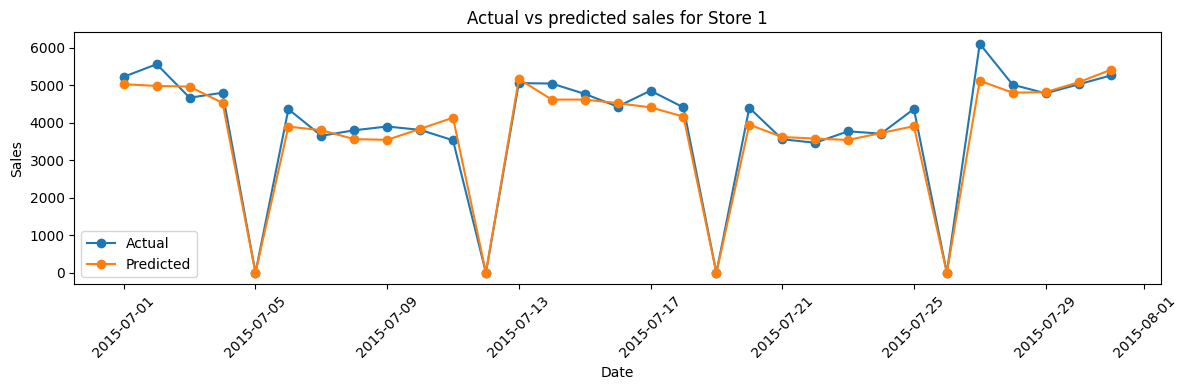

In [43]:
store_id = 1

store_results = results_final[results_final["Store"] == store_id].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(store_results["Date"], store_results["Sales"], marker="o", label="Actual")
plt.plot(store_results["Date"], store_results["Prediction"], marker="o", label="Predicted")
plt.title(f"Actual vs predicted sales for Store {store_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 19. What have we done?

We have completed a full forecasting workflow:

1. Loaded real store sales data.
2. Joined daily sales data with store descriptions.
3. Created a transparent time-based test period.
4. Built a baseline forecast.
5. Engineered calendar, store, promotion and recent-history features.
6. Trained XGBoost regression models.
7. Evaluated using RMSPE.
8. Inspected feature importance and prediction errors.

This mirrors the logic of a strong competition solution, although it is much simpler than the original winning ensemble.

## 20. Possible extensions

To move closer to a full winning-style strategy, we could add:

- a separate validation period before the final test month;
- more recent-history features;
- features based on holidays and promotion intervals;
- different XGBoost parameter settings;
- several models with different random seeds;
- an ensemble of models;
- more careful feature selection;
- a final comparison with the official Kaggle scoring approach.